In [2]:
import json

data_count = []
with open('cve_analysis_count.jsonl', 'r') as file:
    for line in file:
        json_object = json.loads(line.strip())
        data_count.append(json_object)

In [3]:
total_count = [0,0,0,0]
for d in data_count:
    total_count = [x + y for x, y in zip(total_count, d['outdated_score_class'])]

In [6]:
category_dict = {}
with open('./integrate-example/61k_classified_apps_deberta_multi_v2_not_in_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        category_dict[obj['app_id']] = obj['category']
with open('./integrate-example/61k_app_categories_from_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        category_dict[obj['app_id']] = obj['genre']

In [7]:
## categorize
output_dict = {}
for d in data_count:
    try:
        category = category_dict[d['app_name']]
    except Exception as e:
        category = 'none'
        pass
    if category not in output_dict:
        output_dict[category] = d['outdated_score_class']
    else:
        output_dict[category] = [x + y for x, y in zip(output_dict[category], d['outdated_score_class'])]

In [15]:
filtered_data = {
    k: v for k, v in output_dict.items() if sum(v) >= 100
}

# Extract values while preserving order
values = list(filtered_data.values())

# Transpose lists (index-wise grouping)
restructured = list(map(list, zip(*values)))

In [16]:
restructured[0]

[106, 464, 289, 138, 584, 155, 508, 267, 43, 7, 67, 11, 17, 4]

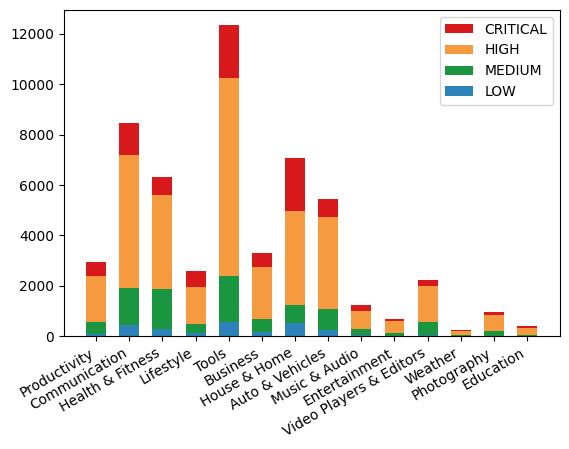

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = list(filtered_data.keys())
levels = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

data = {
    "LOW":      restructured[0],
    "MEDIUM":   restructured[1],
    "HIGH":     restructured[2],
    "CRITICAL": restructured[3],
}
colors = {
    "CRITICAL": "#d7191c",
    "HIGH":     "#f69a3f",
    "MEDIUM":   '#1a9641',
    "LOW":      "#2b83ba",
}

width = 0.6
bottom = np.zeros(len(categories))

fig, ax = plt.subplots()
# fig.set_size_inches(12, 8)

for level, values in data.items():
    ax.bar(categories, values, width, label=level, bottom=bottom, color=colors[level])
    bottom += values

# ax.set_title("Risk Levels per Category")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
fig.autofmt_xdate()
plt.savefig('./plot/cve-library-count.pdf', bbox_inches='tight')


In [24]:
## categorize count
output_dict_count = {}
total_dict = {}
for d in data_count:
    try:
        category = category_dict[d['app_name']]
    except Exception as e:
        category = 'Etc'
        pass
    if category not in output_dict_count:
        total_dict[category] = 1
        marks = [0,0]
        if d['outdated_library'] > 0:
            marks[0] = 1
        if d['outdated_library_candidate'] > 0:
            marks[1] = 1
        output_dict_count[category] = marks
    else:
        total_dict[category] += 1
        tmp_marks = [0,0]
        if d['outdated_library'] > 0:
            tmp_marks[0] = 1
        if d['outdated_library_candidate'] > 0:
            tmp_marks[1] = 1
        output_dict_count[category] = [x + y for x, y in zip(output_dict_count[category], tmp_marks)]

In [30]:
filtered_total_dict = {
    k: v for k, v in total_dict.items() if v >= 100
}
# total_dict

In [31]:
filtered_output_dict_count = {}
for item in filtered_total_dict.keys():
    filtered_output_dict_count[item] = output_dict_count[item]

In [32]:
filtered_output_dict_count

{'Productivity': [1701, 3253],
 'Communication': [5247, 11073],
 'Health & Fitness': [3507, 5578],
 'Lifestyle': [1275, 2423],
 'Tools': [7566, 15139],
 'Business': [1876, 3111],
 'House & Home': [3142, 5449],
 'Auto & Vehicles': [3368, 6166],
 'Music & Audio': [872, 2035],
 'Entertainment': [460, 1080],
 'Video Players & Editors': [1479, 3088],
 'Weather': [159, 322],
 'Photography': [615, 1288],
 'Education': [286, 572]}

In [33]:
for key in filtered_output_dict_count:
    print(f"{key} & {round(output_dict_count[key][0]/total_dict[key]*100,2)} & {round(filtered_output_dict_count[key][1]/filtered_total_dict[key]*100,2)} \\\ \hline")

Productivity & 51.89 & 99.24 \\ \hline
Communication & 46.86 & 98.88 \\ \hline
Health & Fitness & 62.69 & 99.71 \\ \hline
Lifestyle & 52.4 & 99.59 \\ \hline
Tools & 49.45 & 98.95 \\ \hline
Business & 59.82 & 99.2 \\ \hline
House & Home & 57.37 & 99.49 \\ \hline
Auto & Vehicles & 54.19 & 99.21 \\ \hline
Music & Audio & 42.47 & 99.12 \\ \hline
Entertainment & 42.28 & 99.26 \\ \hline
Video Players & Editors & 47.65 & 99.48 \\ \hline
Weather & 48.48 & 98.17 \\ \hline
Photography & 46.98 & 98.4 \\ \hline
Education & 49.57 & 99.13 \\ \hline


In [34]:
#####
with open('./cve-search-results/outdated_libs.txt', 'r') as f:
    outdated_cves = f.read().splitlines()

In [37]:
from collections import Counter

element_counts = Counter(outdated_cves)
top_10_frequent = element_counts.most_common(20)
print(top_10_frequent)

[('android', 22288), ('kotlin', 4001), ('google android', 3745), ('org apache', 3359), ('onesignal', 1696), ('microsoft', 1608), ('tencent', 1375), ('org eclipse', 1356), ('tuya smart', 1190), ('tuya', 1108), ('tuya sdk', 1091), ('o4', 968), ('twilio', 937), ('org threeten bp', 635), ('org threeten', 634), ('org apache commons', 554), ('twitter', 442), ('airbnb', 423), ('baidu', 405), ('alibaba', 399)]


In [ ]:
len(cves)

In [ ]:
len(list(set(cves)))

In [ ]:
with open('cve-list.txt', 'w') as f:
    for item in list(set(cves)):
        f.write(item + "\n")